# **Module 02 Lab02: Data Wrangling - Laptop Pricing**

CISC7204 Assgn01 - Lab02 (Laptop Pricing) / Module 06 Final (House Pricing) | mc660725 Gao Si Han

Handle missing data, fix data types, standardize, normalize, binning and indicator variables.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

Read the updated dataset `laptop_mod1.csv`.

In [2]:
df = pd.read_csv("laptop_mod1.csv", header=0)
print(df.info())
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 238 entries, 0 to 237
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      238 non-null    int64  
 1   Manufacturer    238 non-null    str    
 2   Category        238 non-null    int64  
 3   Screen          238 non-null    str    
 4   GPU             238 non-null    int64  
 5   OS              238 non-null    int64  
 6   CPU_core        238 non-null    int64  
 7   Screen_Size_cm  234 non-null    float64
 8   CPU_frequency   238 non-null    float64
 9   RAM_GB          238 non-null    int64  
 10  Storage_GB_SSD  238 non-null    int64  
 11  Weight_kg       233 non-null    float64
 12  Price           238 non-null    int64  
dtypes: float64(3), int64(8), str(2)
memory usage: 24.3 KB
None


,Unnamed: 0,Manufacturer,Category,Screen,GPU,OS,CPU_core,Screen_Size_cm,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_kg,Price
0,0,Acer,4,IPS Panel,2,1,5,35.560,1.6,8,256,1.60,978
1,1,Dell,3,Full HD,1,1,3,39.624,2.0,4,256,2.20,634
2,2,Dell,3,Full HD,1,1,7,39.624,2.7,8,256,2.20,946
3,3,Dell,4,IPS Panel,2,1,5,33.782,1.6,8,128,1.22,1244
4,4,HP,4,Full HD,2,1,7,39.624,1.8,8,256,1.91,837


In [3]:
df[['Screen_Size_cm']] = np.round(df[['Screen_Size_cm']], 2)
df.head()

,Unnamed: 0,Manufacturer,Category,Screen,GPU,OS,CPU_core,Screen_Size_cm,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_kg,Price
0,0,Acer,4,IPS Panel,2,1,5,35.56,1.6,8,256,1.60,978
1,1,Dell,3,Full HD,1,1,3,39.62,2.0,4,256,2.20,634
2,2,Dell,3,Full HD,1,1,7,39.62,2.7,8,256,2.20,946
3,3,Dell,4,IPS Panel,2,1,5,33.78,1.6,8,128,1.22,1244
4,4,HP,4,Full HD,2,1,7,39.62,1.8,8,256,1.91,837


### Task - 1: Evaluate the dataset for missing data

In [4]:
missing_data = df.isnull()
for column in missing_data.columns.values.tolist():
    if missing_data[column].any():
        print(column)
        print(missing_data[column].value_counts())
        print("")

Screen_Size_cm
Screen_Size_cm
False    234
True       4
Name: count, dtype: int64

Weight_kg
Weight_kg
False    233
True       5
Name: count, dtype: int64



### Task - 2: Replace missing values
Continuous attribute Weight_kg -> mean; categorical Screen_Size_cm -> most frequent (mode).

In [5]:
# Weight_kg missing -> mean
avg_weight = df['Weight_kg'].astype('float').mean(axis=0)
print("Mean Weight_kg:", avg_weight)
df['Weight_kg'] = df['Weight_kg'].replace(np.nan, avg_weight)

# Screen_Size_cm missing -> mode
common_screen_size = df['Screen_Size_cm'].value_counts().idxmax()
print("Most frequent Screen_Size_cm:", common_screen_size)
df['Screen_Size_cm'] = df['Screen_Size_cm'].replace(np.nan, common_screen_size)

Mean Weight_kg: 1.8622317596566522
Most frequent Screen_Size_cm: 39.62


### Task - 3: Fix the data types of Weight_kg and Screen_Size_cm to float

In [6]:
df[["Weight_kg","Screen_Size_cm"]] = df[["Weight_kg","Screen_Size_cm"]].astype("float")
print(df.dtypes)

Unnamed: 0          int64
Manufacturer          str
Category            int64
Screen                str
GPU                 int64
OS                  int64
CPU_core            int64
Screen_Size_cm    float64
CPU_frequency     float64
RAM_GB              int64
Storage_GB_SSD      int64
Weight_kg         float64
Price               int64
dtype: object


### Task - 4: Data Standardization
Weight kg -> pounds (x2.205); screen cm -> inch (/2.54). Rename columns accordingly.

In [7]:
df["Weight_kg"] = df["Weight_kg"] * 2.205
df.rename(columns={'Weight_kg':'Weight_pounds'}, inplace=True)
df["Screen_Size_cm"] = df["Screen_Size_cm"] / 2.54
df.rename(columns={'Screen_Size_cm':'Screen_Size_inch'}, inplace=True)
df.head()

,Unnamed: 0,Manufacturer,Category,Screen,GPU,OS,CPU_core,Screen_Size_inch,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_pounds,Price
0,0,Acer,4,IPS Panel,2,1,5,14.000000,1.6,8,256,3.52800,978
1,1,Dell,3,Full HD,1,1,3,15.598425,2.0,4,256,4.85100,634
2,2,Dell,3,Full HD,1,1,7,15.598425,2.7,8,256,4.85100,946
3,3,Dell,4,IPS Panel,2,1,5,13.299213,1.6,8,128,2.69010,1244
4,4,HP,4,Full HD,2,1,7,15.598425,1.8,8,256,4.21155,837


### Data Normalization: normalize CPU_frequency by its maximum

In [8]:
df['CPU_frequency'] = df['CPU_frequency'] / df['CPU_frequency'].max()
df['CPU_frequency'].describe()

count    238.000000
mean       0.813822
std        0.141860
min        0.413793
25%        0.689655
50%        0.862069
75%        0.931034
max        1.000000
Name: CPU_frequency, dtype: float64

### Task - 5: Binning the Price into Low / Medium / High

In [9]:
bins = np.linspace(min(df['Price']), max(df['Price']), 4)
group_names = ['Low','Medium','High']
df['Price-binned'] = pd.cut(df['Price'], bins, labels=group_names, include_lowest=True)
df['Price-binned'].value_counts()

Price-binned
Low       160
Medium     72
High        6
Name: count, dtype: int64

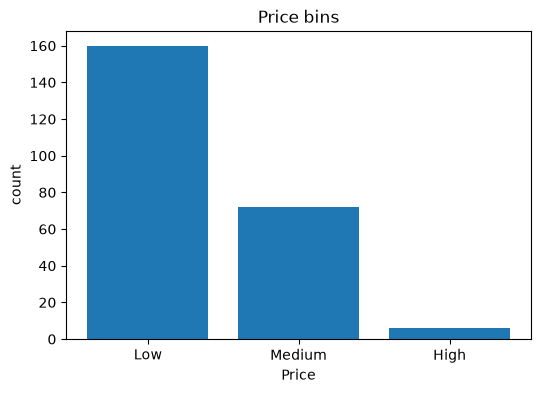

In [10]:
plt.figure(figsize=(6,4))
plt.bar(group_names, df['Price-binned'].value_counts())
plt.xlabel("Price")
plt.ylabel("count")
plt.title("Price bins")
plt.show()

### Task - 6: Indicator variables for Screen (Full HD / IPS panel), drop original Screen

In [11]:
dummy_variable_1 = pd.get_dummies(df['Screen'])
dummy_variable_1.rename(columns={'IPS Panel':'Screen-IPS_panel','Full HD':'Screen-Full_HD'}, inplace=True)
df = pd.concat([df, dummy_variable_1], axis=1)
df.drop('Screen', axis=1, inplace=True)
print(df.head())
print("\nColumns:", list(df.columns))

   Unnamed: 0 Manufacturer  Category  GPU  OS  CPU_core  Screen_Size_inch  \
0           0         Acer         4    2   1         5         14.000000   
1           1         Dell         3    1   1         3         15.598425   
2           2         Dell         3    1   1         7         15.598425   
3           3         Dell         4    2   1         5         13.299213   
4           4           HP         4    2   1         7         15.598425   

   CPU_frequency  RAM_GB  Storage_GB_SSD  Weight_pounds  Price Price-binned  \
0       0.551724       8             256        3.52800    978          Low   
1       0.689655       4             256        4.85100    634          Low   
2       0.931034       8             256        4.85100    946          Low   
3       0.551724       8             128        2.69010   1244          Low   
4       0.620690       8             256        4.21155    837          Low   

   Screen-Full_HD  Screen-IPS_panel  
0           False       

# Congratulations! Module 02 complete. This cleaned dataset is saved for later modules.